# Value-at-risk — defend the number

**The brief.** The regulator wants a one-day 99% value-at-risk and expected shortfall for
the **NASDAQ book**, plus evidence that the model is sound. You have a volatility model
from yesterday. Produce the number and defend it.

*"Defend it"* is the hard half. Any of a dozen methods produces a number; very few survive
a competent challenge. Note how much data you have here — nearly fifty years of daily
backtest — because the power of every test below depends on it.

Each task is small. Do them in order; later cells use names defined earlier.

> Data: `NASDAQCOM.csv`, loaded straight from the web so this runs in Colab.

---
## Setup — run this, then look at the picture

Done for you, including the recursive estimation, which takes a minute or two. Nothing
below may look forward: the GJR parameters are re-estimated every month on an expanding
window with five years of burn-in, and between re-estimations the variance recursion runs
forward with the parameters held fixed. **A model fitted once on the whole sample and then
"backtested" on part of it will pass tests it should fail.**

Your own work starts at Task 1.

In [1]:
!pip install arch -q

1971-02-08 to 2026-09-04,  T = 14013
out-of-sample sigma from 1976-02-04, 580 re-estimations
standardized residuals: sd 1.058, kurtosis 5.06


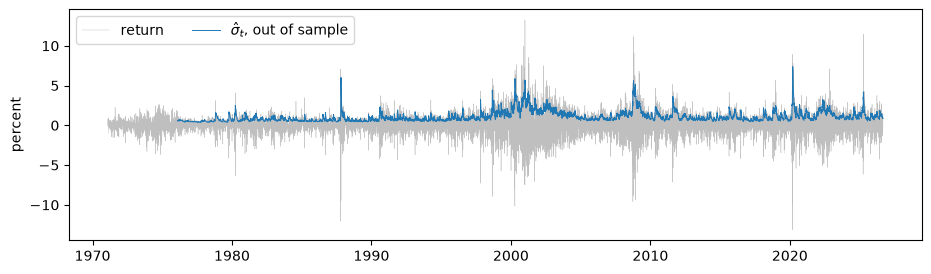

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from arch import arch_model

import warnings; warnings.simplefilter("ignore")

URL = "https://bashtage.github.io/summer-school/"
ALPHA = 0.99

raw = pd.read_csv(URL + "NASDAQCOM.csv")
px = pd.Series(pd.to_numeric(raw["NASDAQCOM"], errors="coerce").to_numpy(),
               index=pd.to_datetime(raw["date"].astype(str), format="%Y%m%d")).dropna()
r = (100 * np.log(px).diff()).dropna()
r.name = "NASDAQ"
T = len(r)
START, STEP = 1260, 22          # five years of burn-in; re-estimate monthly


def rolling_sigma(r, start, step, o=1):
    """One-step-ahead conditional sd and mean, re-estimated every `step` days.

    Parameters come from an expanding window; between re-estimations the variance
    recursion is filtered forward with them held fixed. The sd used on day t therefore
    depends only on returns through t-1.
    """
    spec = lambda y: arch_model(y, mean="Constant", p=1, o=o, q=1)
    sig = pd.Series(np.nan, index=r.index)
    mu = pd.Series(np.nan, index=r.index)
    for t0 in range(start, len(r), step):
        res = spec(r.iloc[:t0]).fit(disp="off", show_warning=False)
        fx = spec(r).fix(res.params)
        hi = min(t0 + step, len(r))
        sig.iloc[t0:hi] = np.asarray(fx.conditional_volatility)[t0:hi]
        mu.iloc[t0:hi] = float(res.params["mu"])
    sig, mu = sig.iloc[start:], mu.iloc[start:]
    return sig, mu, (r.iloc[start:] - mu) / sig


sigma, mu, z = rolling_sigma(r, START, STEP)
print(f"{r.index[0]:%Y-%m-%d} to {r.index[-1]:%Y-%m-%d},  T = {T}")
print(f"out-of-sample sigma from {sigma.index[0]:%Y-%m-%d}, "
      f"{len(range(START, T, STEP))} re-estimations")
print(f"standardized residuals: sd {z.std():.3f}, kurtosis {stats.kurtosis(z.dropna(), fisher=False):.2f}")

fig, ax = plt.subplots(figsize=(11, 3.0))
ax.plot(r.index, r, lw=0.3, color="0.75", label="return")
ax.plot(sigma.index, sigma, lw=0.7, color="tab:blue", label=r"$\hat\sigma_t$, out of sample")
ax.set_ylabel("percent"); ax.legend(ncol=2); plt.show()

---
# Step 1 — Three ways to fill one template

Every conditional method has the same shape: model the conditional distribution, take its
$1-\alpha$ quantile, negate. **They differ only in how the distribution is obtained.**

| | Variance | Quantile |
|---|---|---|
| RiskMetrics | EWMA, $\lambda = 0.94$ | normal |
| Parametric GARCH | GJR-GARCH | normal |
| Filtered historical simulation | GJR-GARCH | **empirical**, from $\hat e_t$ |

## Task 1 — Build the RiskMetrics variance

An exponentially weighted moving average, $\sigma^2_t = (1-\lambda)\epsilon^2_{t-1} +
\lambda\sigma^2_{t-1}$ with $\lambda = 0.94$. Nothing is estimated — but the mean you
centre on and the value you seed the recursion with must still use only past data.

**Key functions**

- `r.expanding().mean().shift(1)` for a backward-looking mean
- seed `ew[0]` with the variance of the burn-in sample, `r.iloc[:START].var()`
- a plain Python loop over `range(1, T)` is fine here

In [ ]:
# Backward-looking mean, and the demeaned return that feeds the recursion.


# Run the EWMA recursion, then keep only the part after the burn-in as `ew`.

---
## Task 2 — Build the three VaR series

The empirical quantile for FHS must be **expanding and lagged**: today's standardized
residual cannot be in the quantile used to set today's VaR.

**Key functions**

- `z.expanding(min_periods=500).quantile(1 - ALPHA).shift(1)`
- `stats.norm.ppf(1 - ALPHA)` for the two normal-quantile methods
- assemble with `pd.DataFrame({...}).dropna()`, then `pd.concat([r, V], axis=1).dropna()`
- the hit indicator for each column is `(al["r"] < -al[c]).astype(int)`

In [ ]:
# The expanding, lagged empirical quantile of the standardized residuals.


# Build a DataFrame `V` with the three VaR series, align with returns into `al`,
# and build the hit indicators `H`.


# Print the sample and, for each method, breaches, rate and expected.

**The count is the easy part.** Before running any test, look at those three numbers and
say which methods you have already ruled out.

---
# Step 2 — Backtesting

## Task 3 — Unconditional coverage

$T_1$ breaches out of $n$. Under $H_0: p = 1-\alpha$, the likelihood ratio

$$LR_{UC} = -2\ln\left[\frac{(1-\alpha)^{T_1}\alpha^{\,n-T_1}}
{\hat p^{\,T_1}(1-\hat p)^{\,n-T_1}}\right] \;\to\; \chi^2_1$$

An ordinary likelihood ratio test of a proportion, applied to a constructed series.

**Key functions**

- `stats.chi2.sf(stat, 1)` for the p-value
- write it as a function `lr_uc(h)` taking the hit array — you will reuse it

In [ ]:
def lr_uc(h, a=ALPHA):
    """Kupiec unconditional coverage test. Returns (statistic, p-value)."""
    ...


# Print the statistic and p-value for each method.

---
## Task 4 — Independence

Getting the count right is not enough: the breaches must also be **unpredictable**. Fit a
two-state Markov chain to the hit sequence and test $p_{01} = p_{11}$, where $p_{ij}$ is
the probability of a breach today given state $i$ yesterday.

**Key functions**

- count the four transitions $n_{00}, n_{01}, n_{10}, n_{11}$ from `h[:-1]` and `h[1:]`
- $\hat p_{01} = n_{01}/(n_{00}+n_{01})$, $\hat p_{11} = n_{11}/(n_{10}+n_{11})$
- the statistic is $-2$ times the difference of restricted and unrestricted
  log-likelihoods, distributed $\chi^2_1$
- report $\hat p_{01}$ and $\hat p_{11}$ as well as the p-value — the ratio between them
  is more informative than the test

In [ ]:
def lr_ind(h):
    """Christoffersen independence test. Returns (statistic, p-value, p01, p11)."""
    ...


# For each method print p01, p11, their ratio, and the p-value.

**Look at the ratio column, not only the p-values.** A breach is roughly one in a hundred
unconditionally. What is it, for each method, on the day after a breach?

---
## Task 5 — Conditional coverage, and the two failures together

$LR_{CC} = LR_{UC} + LR_{IND}$, distributed $\chi^2_2$. It tests the right count **and**
independent breaches at once.

**Key functions**

- just add the two statistics and use `stats.chi2.sf(stat, 2)`

In [ ]:
# For each method, print LR_uc, LR_ind and LR_cc with their p-values, as one table.

---
## Task 6 — The dynamic quantile test

The Markov test looks one day back and ignores the VaR itself. Regress the hit indicator
on more:

$$\mathrm{HIT}_t = \gamma_0 + \gamma_1 \mathrm{HIT}_{t-1} + \cdots + \gamma_K \mathrm{HIT}_{t-K}
+ \gamma_{K+1}\mathrm{VaR}_{t,\alpha} + u_t$$

and test that every coefficient is zero except an intercept of $1-\alpha$. Use $K=4$, so
there are six restrictions and the statistic is $\chi^2_6$.

**Compute it as a quadratic form, not as a Wald test on an OLS.** The obvious
HAC Wald version rejects almost always on hits that are correct by construction:

$$DQ = \frac{(H-p)'X(X'X)^{-1}X'(H-p)}{p(1-p)}$$

**Key functions**

- build `X` with `np.column_stack`: a constant, `K` lagged hits, and the VaR from `K` on
- `np.linalg.pinv(X.T @ X)`
- `stats.chi2.sf(stat, X.shape[1])`

In [ ]:
def dq_test(hit, var, alpha=ALPHA, K=4):
    """Engle-Manganelli dynamic quantile test. Returns (statistic, p-value)."""
    ...


# Print the statistic and p-value for each method, with the chi2(6) critical value.

**Which model survives?** Line up Tasks 3 to 6. One of them gets the count right; check
whether it also gets the *timing* right. If it does not, is it still the one you would
take to the regulator?

---
## Task 7 — See the hits

Plot the return series with each VaR path and its breaches marked, one panel per method.

**Key functions**

- `plt.subplots(3, 1, figsize=(11, 6), sharex=True)`
- breach dates are `al.index[H[c] == 1]`
- put the count and rate in each panel title

In [ ]:
# Three stacked panels: returns in grey, -VaR in blue, breaches as red dots.

---
## Task 8 — How did each one do in a crisis?

Aggregate counts hide timing. Count breaches for each method through the dot-com bust,
the financial crisis and COVID.

**Key functions**

- slice `al.loc[lo:hi]` and recompute the hit within the slice, or slice `H` directly
- expected is `(1 - ALPHA) * len(window)`

In [ ]:
# For each of the three crisis windows, print expected and the three breach counts.

---
# Step 3 — The second number

## Task 9 — Expected shortfall

VaR is a threshold and says nothing about what lies beyond it. Expected shortfall is the
average loss over the worst $1-\alpha$ of outcomes.

Compute the multiplier three ways: the normal one, $-\phi(\Phi^{-1}(1-\alpha))/(1-\alpha)$;
the empirical one, the mean of the standardized residuals at or below their $1-\alpha$
quantile; and then today's VaR and ES in percent.

**Key functions**

- `stats.norm.pdf`, `stats.norm.ppf`
- `zz = z.dropna()`, then `zz[zz <= zz.quantile(1 - ALPHA)].mean()`
- today's numbers use `sigma.iloc[-1]` and `mu.iloc[-1]`

In [ ]:
# The normal and empirical VaR and ES multipliers.


# Today's sigma, and the FHS VaR and ES in percent.

---
# Write the answer to the brief

**1. The number.** Your one-day 99% VaR and expected shortfall, and the method that
produced them. State the backtest window and how the parameters were estimated — the
regulator will ask, and "fitted once on everything" is the wrong answer.

**2. The defense.** The coverage result, the independence result, and the dynamic quantile
result. Quote the two alternatives you rejected and by how much they failed.

**3. The caveats you volunteer rather than wait to be asked.** There is at least one test
your chosen method does *not* pass. Name it, say what it means, and say what you would do
about it. An empirical quantile also cannot exceed the worst standardized residual ever
seen — say what that implies for the deep tail.

**A question to close on.** This backtest has roughly two and a half times as many days as
the one in the lecture. Does that make your conclusion stronger, or does it simply mean
the tests can now see faults that were always there?